In [5]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

In [6]:
# Load averaged results
date_one_to_one_gaussian = "03051301"
with open(f"../Results_averaged/optuna_mixing_capacity_qrc_gaussian_results_{date_one_to_one_gaussian}_combined.pkl", "rb") as f:
    data_one_to_one_gaussian = pickle.load(f)

date_fill_gaussian = "03051521"
with open(f"../Results_averaged/optuna_mixing_capacity_qrc_gaussian_results_{date_fill_gaussian}_combined.pkl", "rb") as f:
    data_fill_gaussian = pickle.load(f)

date_dense_gaussian = "03051418"
with open(f"../Results_averaged/optuna_mixing_capacity_qrc_gaussian_results_{date_dense_gaussian}_combined.pkl", "rb") as f:
    data_dense_gaussian = pickle.load(f)

date_one_to_one_spin = "03051121"
with open(f"../Results_averaged/optuna_mixing_capacity_qrc_tilted_tfim_results_{date_one_to_one_spin}_combined.pkl", "rb") as f:
    data_one_to_one_spin = pickle.load(f)

date_fill_spin = "03052258"
with open(f"../Results_averaged/optuna_mixing_capacity_qrc_tilted_tfim_results_{date_fill_spin}_combined.pkl", "rb") as f:
    data_fill_spin = pickle.load(f)

date_dense_spin = "03052300"
with open(f"../Results_averaged/optuna_mixing_capacity_qrc_tilted_tfim_results_{date_dense_spin}_combined.pkl", "rb") as f:
    data_dense_spin = pickle.load(f)

In [7]:
df2_one_to_one_gaussian = pd.DataFrame(data_one_to_one_gaussian)
df2_fill_gaussian = pd.DataFrame(data_fill_gaussian)
df2_dense_gaussian = pd.DataFrame(data_dense_gaussian)

df2_one_to_one_spin = pd.DataFrame(data_one_to_one_spin)
df2_fill_spin = pd.DataFrame(data_fill_spin)
df2_dense_spin = pd.DataFrame(data_dense_spin)

df2_dense_spin = df2_dense_spin.loc[~np.isneginf(df2_dense_spin["best_score_mean"])].reset_index(drop=True)

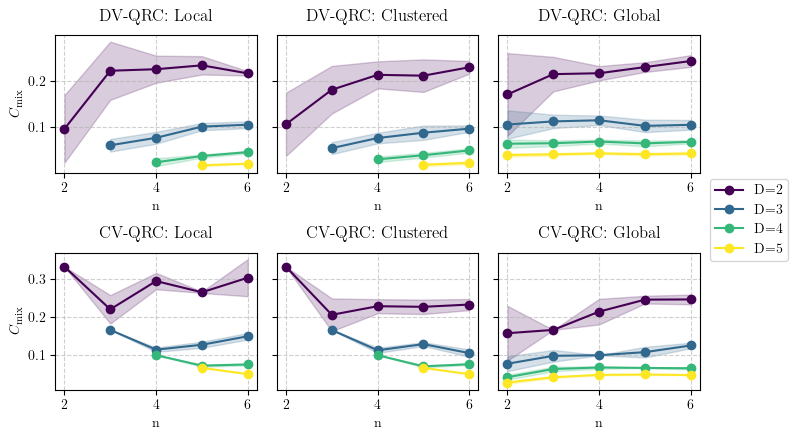

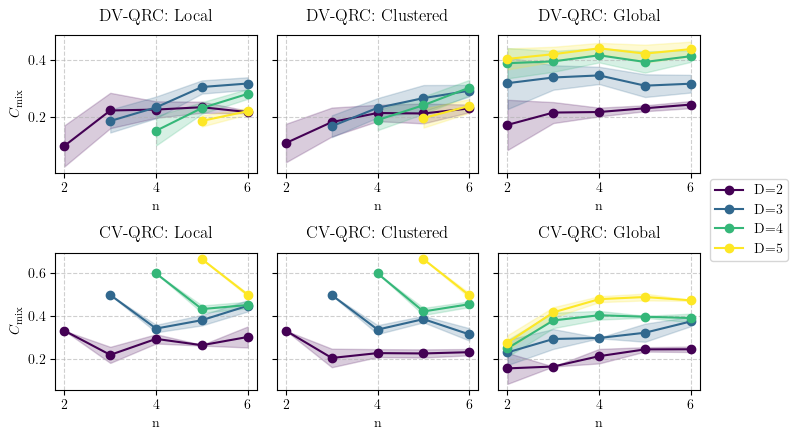

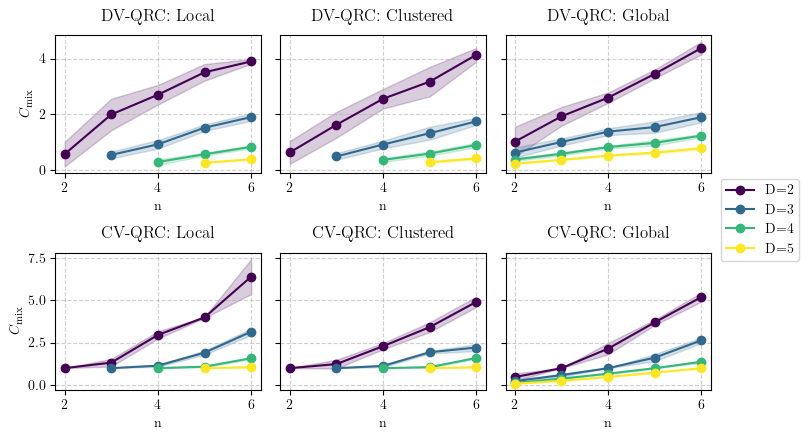

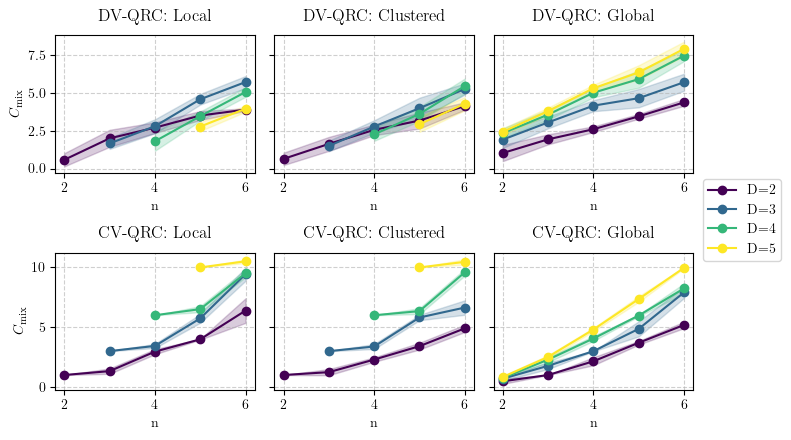


Generated 4 combined figure(s).


In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Group the dataframes by model (Row) and experiment type (Column)
models_data = [
    ("DV-QRC", [
        ("Local", df2_one_to_one_spin),
        ("Clustered", df2_fill_spin),
        ("Global", df2_dense_spin)
    ]),
    ("CV-QRC", [
        ("Local", df2_one_to_one_gaussian),
        ("Clustered", df2_fill_gaussian),
        ("Global", df2_dense_gaussian)
    ])
]

# metrics and threshold setup
metrics = [
    ("best_score_mean", "best_score_std", "best_score"),
    # ("first_and_second_moment_2_mean", "first_and_second_moment_2_std", "first_and_second_moment_2"),
    # ("first_moment_3_mean", "first_moment_3_std", "first_moment_3"),
    # ("first_and_second_moment_3_mean", "first_and_second_moment_3_std", "first_and_second_moment_3"),
]

# Set your limits here
MAX_N = 6
MAX_D = 5

num_figs = 0

for mean_col, std_col, metric_label in metrics:
    
    # Find global min and max 'd' across ALL models and experiments
    all_d_vals = []
    for model_name, experiments in models_data:
        for _, exp_df in experiments:
            df_filtered = exp_df.dropna(subset=[mean_col, std_col])
            df_filtered = df_filtered[(df_filtered["n"] <= MAX_N) & (df_filtered["d"] <= MAX_D)]
            all_d_vals.extend(df_filtered["d"].unique())
        
    if not all_d_vals:
        continue  # Skip if no data at all for this metric
        
    vmin_d, vmax_d = min(all_d_vals), max(all_d_vals)
    
    # Initialize the viridis colormap and normalizer
    cmap = plt.get_cmap("viridis")
    norm = mcolors.Normalize(vmin=vmin_d, vmax=vmax_d) if vmin_d != vmax_d else mcolors.Normalize(vmin=vmin_d-1, vmax=vmax_d+1)
    
    # Loop through all 4 combinations of normalization
    for is_n_normalized in [True, False]:
        for is_d_normalized in [True, False]:
            
            # Create a 2 row, 3 column figure. 
            # Removed sharex=True so models have independent x-ranges.
            fig, axes = plt.subplots(2, 3, figsize=(8, 4.5), sharey='row')
            anything_plotted_in_fig = False
            
            # Dictionary to collect unique legend handles
            legend_handles = {}
            
            # Loop through rows (Models: Spin QRC, Gaussian QRC)
            for row_idx, (model_name, experiments) in enumerate(models_data):
                
                # Loop through columns (Experiments: Local, Clustered, Global)
                for col_idx, (exp_name, exp_df) in enumerate(experiments):
                    ax = axes[row_idx, col_idx]
                    
                    # Drop rows where either mean or std is NaN
                    plot_df = exp_df.dropna(subset=[mean_col, std_col]).copy()
                    
                    # Filter the dataframe to limit n and d
                    plot_df = plot_df[(plot_df["n"] <= MAX_N) & (plot_df["d"] <= MAX_D)]
                    
                    d_vals = sorted(plot_df["d"].unique())
                    
                    if len(d_vals) == 0:
                        ax.set_title(f"{model_name}: {exp_name}\n(No data)")
                        continue
                    
                    anything_plotted_in_ax = False

                    for d_val in d_vals:
                        d_df = plot_df[plot_df["d"] == d_val].sort_values(by="n")
                        
                        if d_df.empty:
                            continue
                            
                        x = d_df["n"]
                        y_mean = d_df[mean_col].copy()
                        y_std = d_df[std_col].copy()
                        
                        # --- MODIFIED SECTION STARTS HERE ---
                        factor = 1.0
                        if not is_n_normalized:
                            if "CV-QRC" in model_name:
                                factor = factor * (x * (x + 1) / 2)
                            elif "DV-QRC" in model_name:
                                factor = factor * (3 * x)
                                
                        if is_d_normalized:
                            factor = factor / (d_val * (d_val - 1) / 2)
                        # --- MODIFIED SECTION ENDS HERE ---
                        
                        y_mean = y_mean * factor
                        y_std = y_std * factor
                        
                        line_color = cmap(norm(d_val))
                        
                        # Plot mean line and standard deviation
                        line = ax.plot(x, y_mean, marker='o', label=f"D={d_val:g}", color=line_color)
                        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2, color=line_color)
                        
                        # Save the line handle for the global legend
                        if d_val not in legend_handles:
                            legend_handles[d_val] = line[0]
                        
                        anything_plotted_in_ax = True
                        anything_plotted_in_fig = True

                    # Formatting for the specific subplot
                    if anything_plotted_in_ax:
                        # Write the Model Name and Encoding Method on every subplot
                        ax.set_title(f"{model_name}: {exp_name}", pad=10)
                        
                        # Set x-labels for all plots since they are now independent
                        ax.set_xlabel("n")
                        
                        # Force integer ticks on the x-axis
                        # ax.set_xticks(range(2, MAX_N + 1))
                        ax.grid(True, linestyle='--', alpha=0.6)
                        
                        # Set y-labels (Metric ONLY) on the far left column
                        if col_idx == 0:
                            ax.set_ylabel(r"$C_\mathrm{mix}$")

            # Handle the overall figure
            if anything_plotted_in_fig:
                # Add a single master legend to the center-right of the figure
                sorted_d_keys = sorted(legend_handles.keys())
                handles = [legend_handles[d] for d in sorted_d_keys]
                labels = [f"D={d:g}" for d in sorted_d_keys]
                
                fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.00, 0.5))
                
                # Use rect to compress the subplots slightly to the left, leaving 10% space for the legend
                plt.tight_layout(rect=[0, 0, 0.9, 1])
                plt.savefig(f"../Plots/combined_{metric_label}_nNorm_{is_n_normalized}_dNorm_{is_d_normalized}.pdf", bbox_inches='tight')
                plt.show()
                
                num_figs += 1
            else:
                plt.close(fig)

print(f"\nGenerated {num_figs} combined figure(s).")